In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from math import sqrt

from sklearn.metrics import (mean_squared_error as MSE, mean_absolute_error as MAE, r2_score as R2,
                             explained_variance_score as EVS)
from sklearn.preprocessing import RobustScaler

from keras.models import load_model

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 8)

/home/bulent/anaconda3/lib/python3.6/site-packages/h5py/__init__.py:34: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [2]:
def fraction_within_eps(y_true, y_pred, epsilon=0.5):
    # fraction of entries where abs(y_true - y_pred) < epsilon
    
    count = np.sum(np.abs(y_true - y_pred) <= epsilon)
    return count / y_true.shape[0]

yt = np.array([10, 10, 10, 10, 10])
yp = np.array([9.2, 9.7, 10.3, 10.2, 11])
print(fraction_within_eps(yt, yp, 0.6))
FIE = fraction_within_eps

0.6


In [3]:
def concorr(x, y):
    # Return Lin's concordance correlation coefficient
    # x, y are numpy arrays
    
    xm = x.mean()
    ym = y.mean()
    xv = x.var()
    yv = y.var()
    xycov = np.sum((x-xm)*(y-ym)) / x.shape[0]
    lin = 2*xycov / (xv + yv + (xm - ym)**2)
    return lin

xx = np.random.randn(10)
yy = xx + 10
print('R2 corr coef is {} whereas concordance corr coef is {}'.format(R2(yy,xx), concorr(yy,xx)))

R2 corr coef is -162.1715319740365 whereas concordance corr coef is 0.012108624144228336


In [4]:
with open('stations-6to31.pkl', 'rb') as f:
    datas = pickle.load(f)
    
x_train6_ = datas['x_train6']
y_train6 = datas['y_train6']
x_train_ = datas['x_train']
y_train = datas['y_train']
x_dev_ = datas['x_dev']
y_dev = datas['y_dev']
x_test_ = datas['x_test']
y_test = datas['y_test']

print(f'x_train shape: {x_train_.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [5]:
def scale_data(scaler, datas):
    # scaler is a scaling function from sklearn library
    # datas is a dictionary, containing 3 sets of x_data with keys - x_train, x_dev, x_test
    # fit on x_train and return the transformed sets of data
    
    x_train = scaler.fit_transform(datas['x_train'].astype(float))
    x_dev = scaler.transform(datas['x_dev'].astype(float))
    x_test = scaler.transform(datas['x_test'].astype(float))
    
    transformed = {'x_train': x_train, 'x_dev': x_dev, 'x_test': x_test}
    return transformed

data6_ = {'x_train': x_train6_, 'x_dev': x_dev_, 'x_test': x_test_}
data_ = {'x_train': x_train_, 'x_dev': x_dev_, 'x_test': x_test_}

data6 = scale_data(RobustScaler(), data6_)
data = scale_data(RobustScaler(), data_)

x_train6 = data6['x_train']
x_train = data['x_train']

x_dev6 = data6['x_dev']
x_dev = data['x_dev']

x_test6 = data6['x_test']
x_test = data['x_test']

print(f'x_train shape: {x_train.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [6]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test6 = []
metrics_train6 = []
metrics_dev6 = []
print('Evaluating metrics for 6station trained NN \n')
for i in range(50):
    modelname = './6to31stats-4vars-h/6stations-h-nNTPhiH0 {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test6, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev6, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train6, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_train6, p )
    rmse = sqrt( mse )
    mae = MAE( y_train6, p )
    r2 = R2( y_train6, p )
    evs = EVS( y_train6, p )
    fie_h = FIE( y_train6, p, 0.5)
    fie_o = FIE( y_train6, p, 1)
    fie_oh = FIE( y_train6, p, 1.5)
    lin = concorr(y_train6, p)

    metrics_train6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 6station trained NN 

C01 » RMSE: 4.1314, MAE: 2.3328, R2: 0.7677, EVS: 0.7950, FIE_H: 0.1892, FIE_O: 0.3645, FIE_OH: 0.5245, LINCC: 0.8821
C01 » RMSE: 2.8000, MAE: 1.9856, R2: 0.8839, EVS: 0.9071, FIE_H: 0.1842, FIE_O: 0.3588, FIE_OH: 0.5024, LINCC: 0.9426
C01 » RMSE: 3.9521, MAE: 2.2318, R2: 0.8173, EVS: 0.8197, FIE_H: 0.1765, FIE_O: 0.3437, FIE_OH: 0.5089, LINCC: 0.9016
C02 » RMSE: 4.1237, MAE: 2.2531, R2: 0.7685, EVS: 0.7910, FIE_H: 0.2090, FIE_O: 0.3942, FIE_OH: 0.5519, LINCC: 0.8792
C02 » RMSE: 2.6218, MAE: 1.8271, R2: 0.8982, EVS: 0.9128, FIE_H: 0.1981, FIE_O: 0.3844, FIE_OH: 0.5457, LINCC: 0.9480
C02 » RMSE: 3.8882, MAE: 2.1825, R2: 0.8232, EVS: 0.8247, FIE_H: 0.1954, FIE_O: 0.3821, FIE_OH: 0.5376, LINCC: 0.9019
C03 » RMSE: 3.8669, MAE: 2.0750, R2: 0.7965, EVS: 0.8032, FIE_H: 0.2316, FIE_O: 0.4388, FIE_OH: 0.6030, LINCC: 0.8977
C03 » RMSE: 2.5931, MAE: 1.7788, R2: 0.9004, EVS: 0.9046, FIE_H: 0.2097, FIE_O: 0.4018, FIE_OH: 0.5614, LINCC: 0.9515
C03 » RMSE:

C24 » RMSE: 3.8737, MAE: 2.1892, R2: 0.8245, EVS: 0.8262, FIE_H: 0.1931, FIE_O: 0.3701, FIE_OH: 0.5182, LINCC: 0.9032
C25 » RMSE: 4.0076, MAE: 2.1110, R2: 0.7814, EVS: 0.7892, FIE_H: 0.2454, FIE_O: 0.4409, FIE_OH: 0.6006, LINCC: 0.8909
C25 » RMSE: 2.5538, MAE: 1.7481, R2: 0.9034, EVS: 0.9076, FIE_H: 0.2134, FIE_O: 0.4045, FIE_OH: 0.5697, LINCC: 0.9533
C25 » RMSE: 3.9856, MAE: 2.0231, R2: 0.8142, EVS: 0.8146, FIE_H: 0.2293, FIE_O: 0.4371, FIE_OH: 0.6116, LINCC: 0.9025
C26 » RMSE: 4.1909, MAE: 2.2106, R2: 0.7609, EVS: 0.7774, FIE_H: 0.2268, FIE_O: 0.4216, FIE_OH: 0.5770, LINCC: 0.8808
C26 » RMSE: 2.6604, MAE: 1.8660, R2: 0.8952, EVS: 0.9054, FIE_H: 0.1892, FIE_O: 0.3684, FIE_OH: 0.5307, LINCC: 0.9489
C26 » RMSE: 3.8771, MAE: 2.0207, R2: 0.8242, EVS: 0.8244, FIE_H: 0.2191, FIE_O: 0.4211, FIE_OH: 0.5924, LINCC: 0.9068
C27 » RMSE: 4.7281, MAE: 2.3033, R2: 0.6957, EVS: 0.7139, FIE_H: 0.2285, FIE_O: 0.4154, FIE_OH: 0.5706, LINCC: 0.8506
C27 » RMSE: 2.6859, MAE: 1.8639, R2: 0.8932, EVS: 0.9069

C48 » RMSE: 4.3710, MAE: 2.2504, R2: 0.7399, EVS: 0.7494, FIE_H: 0.2295, FIE_O: 0.4224, FIE_OH: 0.5793, LINCC: 0.8730
C48 » RMSE: 2.6169, MAE: 1.8467, R2: 0.8986, EVS: 0.9041, FIE_H: 0.1951, FIE_O: 0.3761, FIE_OH: 0.5378, LINCC: 0.9510
C48 » RMSE: 3.9533, MAE: 2.0261, R2: 0.8172, EVS: 0.8176, FIE_H: 0.2225, FIE_O: 0.4306, FIE_OH: 0.6026, LINCC: 0.9041
C49 » RMSE: 4.4289, MAE: 2.2127, R2: 0.7330, EVS: 0.7442, FIE_H: 0.2300, FIE_O: 0.4292, FIE_OH: 0.5905, LINCC: 0.8687
C49 » RMSE: 2.5689, MAE: 1.7527, R2: 0.9023, EVS: 0.9094, FIE_H: 0.2146, FIE_O: 0.4146, FIE_OH: 0.5813, LINCC: 0.9523
C49 » RMSE: 3.9447, MAE: 2.0770, R2: 0.8180, EVS: 0.8180, FIE_H: 0.2095, FIE_O: 0.4086, FIE_OH: 0.5787, LINCC: 0.9041
C50 » RMSE: 4.5810, MAE: 2.2900, R2: 0.7144, EVS: 0.7320, FIE_H: 0.2211, FIE_O: 0.4162, FIE_OH: 0.5736, LINCC: 0.8590
C50 » RMSE: 2.6718, MAE: 1.8548, R2: 0.8943, EVS: 0.9077, FIE_H: 0.2073, FIE_O: 0.3984, FIE_OH: 0.5492, LINCC: 0.9477
C50 » RMSE: 3.8896, MAE: 2.0694, R2: 0.8230, EVS: 0.8236

In [7]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test31 = []
metrics_train31 = []
metrics_dev31 = []
print('Evaluating metrics for 31station trained NN \n')
for i in range(50):
    modelname = './6to31stats-4vars-h/31stations-h-nNTPhiH0 {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_train, p )
    rmse = sqrt( mse )
    mae = MAE( y_train, p )
    r2 = R2( y_train, p )
    evs = EVS( y_train, p )
    fie_h = FIE( y_train, p, 0.5)
    fie_o = FIE( y_train, p, 1)
    fie_oh = FIE( y_train, p, 1.5)
    lin = concorr(y_train, p)

    metrics_train31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 31station trained NN 

C01 » RMSE: 4.1448, MAE: 2.1380, R2: 0.7662, EVS: 0.7837, FIE_H: 0.2209, FIE_O: 0.4291, FIE_OH: 0.5994, LINCC: 0.8798
C01 » RMSE: 2.2609, MAE: 1.4480, R2: 0.9243, EVS: 0.9317, FIE_H: 0.2671, FIE_O: 0.5103, FIE_OH: 0.6825, LINCC: 0.9618
C01 » RMSE: 3.0468, MAE: 1.6862, R2: 0.8754, EVS: 0.8756, FIE_H: 0.2490, FIE_O: 0.4744, FIE_OH: 0.6500, LINCC: 0.9345
C02 » RMSE: 4.2056, MAE: 2.0596, R2: 0.7592, EVS: 0.7711, FIE_H: 0.2522, FIE_O: 0.4742, FIE_OH: 0.6402, LINCC: 0.8796
C02 » RMSE: 2.2929, MAE: 1.4834, R2: 0.9221, EVS: 0.9271, FIE_H: 0.2627, FIE_O: 0.4972, FIE_OH: 0.6763, LINCC: 0.9617
C02 » RMSE: 3.0282, MAE: 1.6379, R2: 0.8769, EVS: 0.8769, FIE_H: 0.2617, FIE_O: 0.4979, FIE_OH: 0.6739, LINCC: 0.9367
C03 » RMSE: 4.2630, MAE: 2.0657, R2: 0.7526, EVS: 0.7627, FIE_H: 0.2589, FIE_O: 0.4740, FIE_OH: 0.6358, LINCC: 0.8770
C03 » RMSE: 2.2674, MAE: 1.4538, R2: 0.9239, EVS: 0.9279, FIE_H: 0.2811, FIE_O: 0.5098, FIE_OH: 0.6826, LINCC: 0.9627
C03 » RMSE

C24 » RMSE: 2.2686, MAE: 1.4442, R2: 0.9238, EVS: 0.9295, FIE_H: 0.2922, FIE_O: 0.5275, FIE_OH: 0.6867, LINCC: 0.9612
C24 » RMSE: 3.0088, MAE: 1.6544, R2: 0.8784, EVS: 0.8785, FIE_H: 0.2602, FIE_O: 0.4912, FIE_OH: 0.6634, LINCC: 0.9356
C25 » RMSE: 4.0128, MAE: 2.0348, R2: 0.7808, EVS: 0.7964, FIE_H: 0.2492, FIE_O: 0.4643, FIE_OH: 0.6315, LINCC: 0.8852
C25 » RMSE: 2.2616, MAE: 1.4259, R2: 0.9243, EVS: 0.9301, FIE_H: 0.2844, FIE_O: 0.5348, FIE_OH: 0.6970, LINCC: 0.9612
C25 » RMSE: 2.9997, MAE: 1.6316, R2: 0.8792, EVS: 0.8792, FIE_H: 0.2726, FIE_O: 0.5056, FIE_OH: 0.6723, LINCC: 0.9354
C26 » RMSE: 3.9857, MAE: 2.0268, R2: 0.7838, EVS: 0.7984, FIE_H: 0.2476, FIE_O: 0.4683, FIE_OH: 0.6347, LINCC: 0.8887
C26 » RMSE: 2.2272, MAE: 1.4095, R2: 0.9265, EVS: 0.9319, FIE_H: 0.2845, FIE_O: 0.5391, FIE_OH: 0.7049, LINCC: 0.9631
C26 » RMSE: 3.0091, MAE: 1.6279, R2: 0.8784, EVS: 0.8784, FIE_H: 0.2715, FIE_O: 0.5079, FIE_OH: 0.6761, LINCC: 0.9363
C27 » RMSE: 4.1555, MAE: 2.0118, R2: 0.7650, EVS: 0.7747

C47 » RMSE: 3.0185, MAE: 1.6297, R2: 0.8777, EVS: 0.8777, FIE_H: 0.2719, FIE_O: 0.5079, FIE_OH: 0.6766, LINCC: 0.9360
C48 » RMSE: 4.0553, MAE: 2.0723, R2: 0.7762, EVS: 0.7950, FIE_H: 0.2481, FIE_O: 0.4548, FIE_OH: 0.6173, LINCC: 0.8832
C48 » RMSE: 2.3115, MAE: 1.4553, R2: 0.9209, EVS: 0.9292, FIE_H: 0.2888, FIE_O: 0.5315, FIE_OH: 0.6912, LINCC: 0.9595
C48 » RMSE: 3.0000, MAE: 1.6452, R2: 0.8791, EVS: 0.8795, FIE_H: 0.2690, FIE_O: 0.5003, FIE_OH: 0.6687, LINCC: 0.9356
C49 » RMSE: 4.1786, MAE: 2.1175, R2: 0.7623, EVS: 0.7812, FIE_H: 0.2456, FIE_O: 0.4517, FIE_OH: 0.6172, LINCC: 0.8786
C49 » RMSE: 2.3304, MAE: 1.4845, R2: 0.9196, EVS: 0.9286, FIE_H: 0.2841, FIE_O: 0.5223, FIE_OH: 0.6751, LINCC: 0.9594
C49 » RMSE: 3.0239, MAE: 1.6580, R2: 0.8772, EVS: 0.8779, FIE_H: 0.2628, FIE_O: 0.4945, FIE_OH: 0.6649, LINCC: 0.9357
C50 » RMSE: 3.9645, MAE: 2.0029, R2: 0.7861, EVS: 0.7984, FIE_H: 0.2586, FIE_O: 0.4746, FIE_OH: 0.6410, LINCC: 0.8905
C50 » RMSE: 2.2801, MAE: 1.4606, R2: 0.9230, EVS: 0.9274

In [8]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

with open('measures_6to31_nNTPhi_h.pkl', 'wb') as f:
    pickle.dump(measures, f)

In [8]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

mess = ['rmse', 'mae', 'r2', 'evs', 'fie_h', 'fie_o', 'fie_oh', 'lin']
test6 = np.array(measures['te6']).T # 8x50
test31 = np.array(measures['te31']).T
for i in range(8):
    exec(f'{mess[i]} = np.array([test6[i], test31[i]])')
    exec(f'{mess[i]} = {mess[i]}.T')
    
print(rmse.shape)

(50, 2)


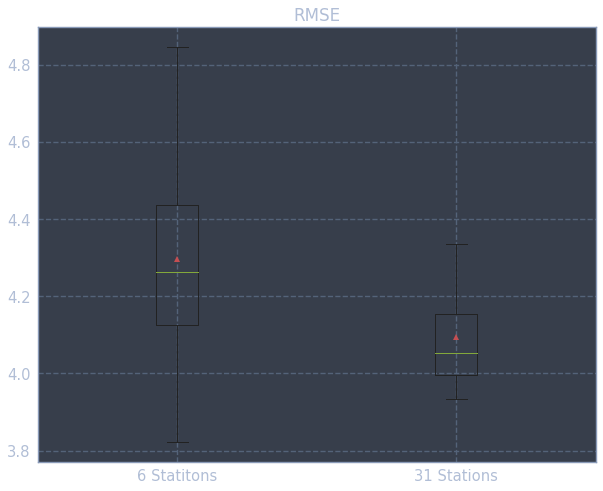

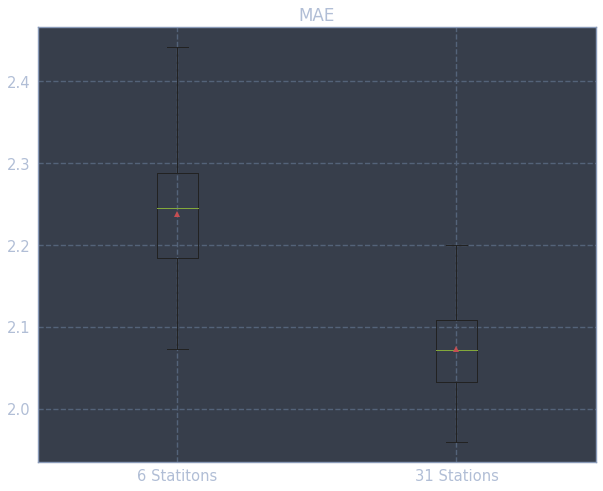

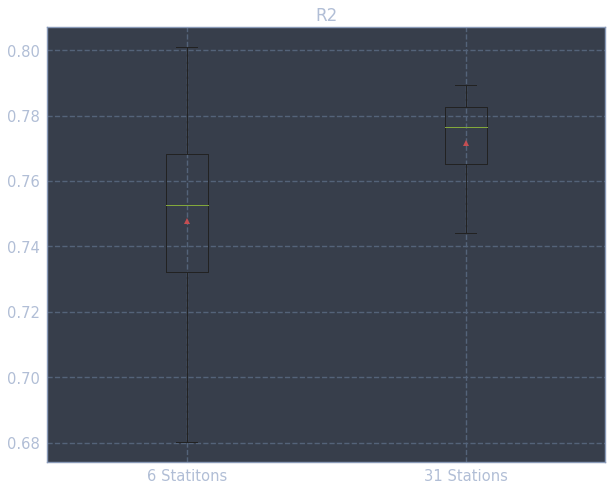

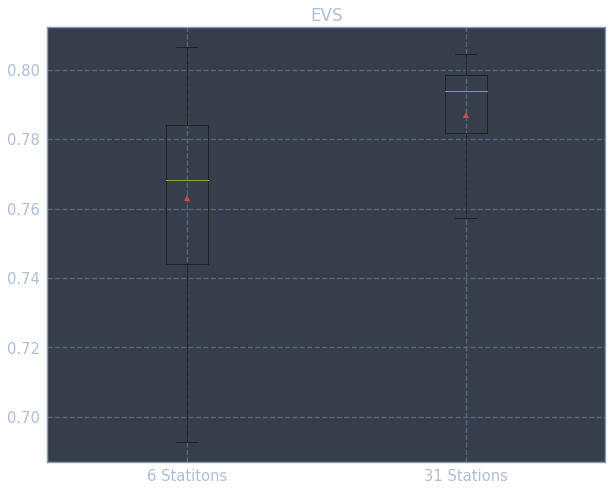

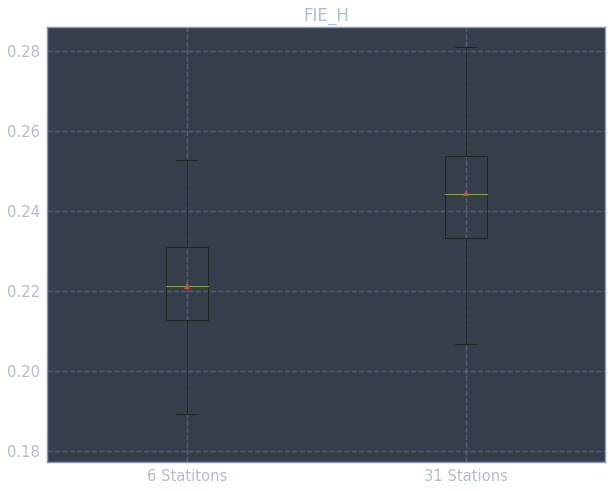

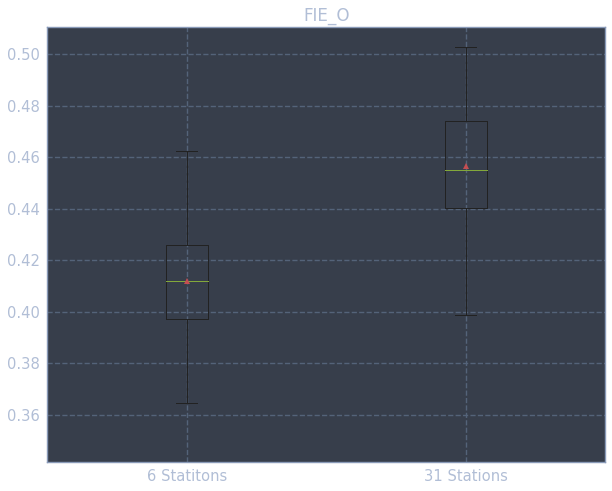

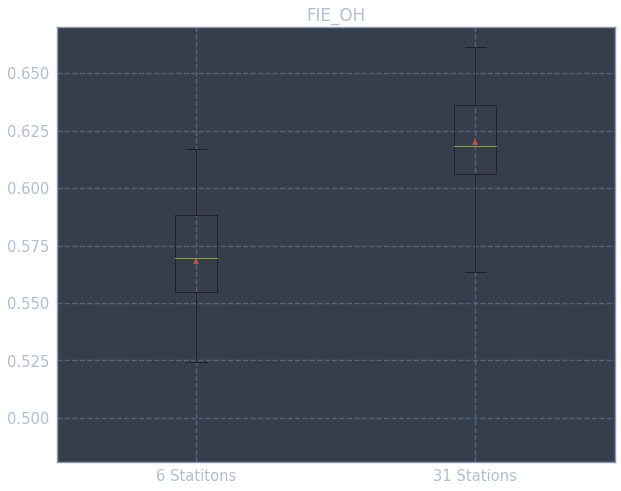

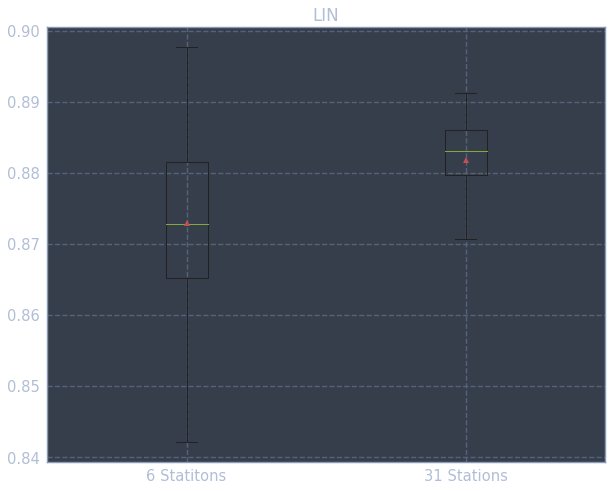

In [9]:
# I want a boxplot for each measure, showing test set comparison for 6station and 31station trained NNs
# plt.boxplot(x) makes a box for each column in x, so I need to feed 50x2 arrays to it

n = 0
for m in mess:
    plt.figure(n)
    exec(f'plt.boxplot({m}, labels=["6 Statitons", "31 Stations"], showmeans=True)')
    plt.title(m.upper())
    n += 1